In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving german_credit_data.csv to german_credit_data.csv
{'german_credit_data.csv': b'status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target\r\n< 0 DM,6,critical account/ other credits existing (not at this bank),radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good\r\n0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad\r\nno checking account,12,critical account/ other credits existing (not at this bank),education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,

In [3]:
df=pd.read_csv('german_credit_data.csv')

In [4]:
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [5]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [6]:
df.shape

(1000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [8]:
df['target'].value_counts()

,count
target,
good,700
bad,300


In [ ]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='target'>

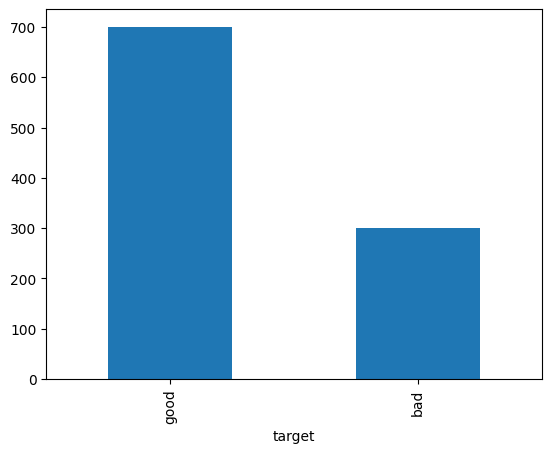

In [ ]:
df['target'].value_counts().plot(kind='bar')

In [9]:
df.isnull().sum()

,0
status_account,0
month_duration,0
credit_history,0
purpose,0
credit_amount,0
status_savings,0
years_employment,0
payment_to_income_ratio,0
status_and_sex,0
secondary_obligor,0


In [10]:
df_encode=df

In [11]:
#Applying label encoding on the target column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encode['target'] = le.fit_transform(df_encode['target'])

In [12]:
df['years_employment'].value_counts()

,count
years_employment,
1 to < 4 years,339
>= 7 years,253
4 to < 7 years,174
< 1 year,172
unemployed,62


In [13]:
print(df['years_employment'].unique())

['>= 7 years' '1 to < 4 years' '4 to < 7 years' 'unemployed' '< 1 year']


<Axes: xlabel='years_employment', ylabel='count'>

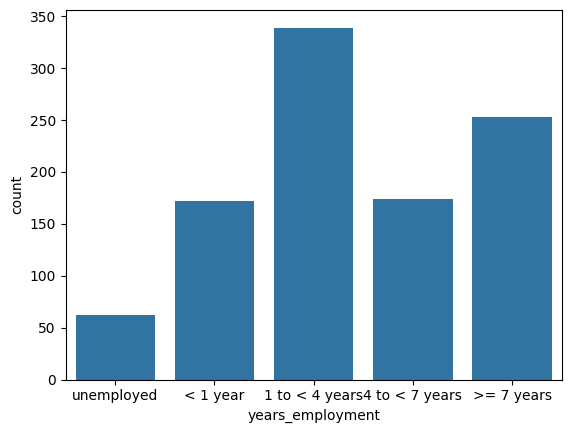

In [14]:
order = ['unemployed','< 1 year','1 to < 4 years','4 to < 7 years','>= 7 years']
sns.countplot(x='years_employment',data=df,order=order)

In [15]:
#Applying Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
encoder1 = OrdinalEncoder(
    categories=[[
        'unemployed',
        '< 1 year',
        '1 to < 4 years',
        '4 to < 7 years',
        '>= 7 years'
    ]]
)
df_encode['years_employment'] = encoder1.fit_transform(
    df_encode[['years_employment']]
)

In [16]:
df_encode['status_account'].value_counts()

,count
status_account,
no checking account,394
< 0 DM,274
0 to < 200 DM,269
>= 200 DM,63


In [17]:
from sklearn.preprocessing import OrdinalEncoder
encoder2 = OrdinalEncoder(categories=[[
    '< 0 DM',
    '0 to < 200 DM',
    '>= 200 DM',
    'no checking account'
]])
df_encode[['status_account']] = encoder2.fit_transform(df_encode[['status_account']])

In [18]:
df_encode['credit_history'].value_counts()

,count
credit_history,
existing credits paid back duly till now,530
critical account/ other credits existing (not at this bank),293
delay in paying off in the past,88
all credits at this bank paid back duly,49
no credits taken/ all credits paid back duly,40


In [19]:
#for credit scoring , it often makes sense that the best credit history must get higher number compared to the worst credit history, so the ordering is done in that order
encoder3 = OrdinalEncoder(categories=[[
    'critical account/ other credits existing (not at this bank)',
    'delay in paying off in the past',
    'existing credits paid back duly till now',
    'all credits at this bank paid back duly',
    'no credits taken/ all credits paid back duly'
]])
df_encode[['credit_history']] = encoder3.fit_transform(
    df_encode[['credit_history']]
)

In [20]:
df_encode['purpose'].value_counts()

,count
purpose,
radio/television,280
car (new),234
furniture/equipment,181
car (used),103
business,97
education,50
repairs,22
domestic appliances,12
others,12


In [21]:
df_encode = pd.get_dummies(df_encode,columns=['purpose'],drop_first=True,dtype=int)

In [22]:
df_encode['housing'].value_counts()

,count
housing,
own,713
rent,179
for free,108


In [23]:
df_encode = pd.get_dummies(df_encode,columns=['housing'],drop_first=True,dtype=int)

In [24]:
df_encode['status_savings'].value_counts()

,count
status_savings,
< 100 DM,603
unknown/ no savings account,183
100 to < 500 DM,103
500 to < 1000 DM,63
>= 1000 DM,48


In [25]:
from sklearn.preprocessing import OrdinalEncoder
encoder4 = OrdinalEncoder(categories=[[
    'unknown/ no savings account',
    '< 100 DM',
    '100 to < 500 DM',
    '500 to < 1000 DM',
    '>= 1000 DM'
]])

df_encode[['status_savings']] = encoder4.fit_transform(
    df_encode[['status_savings']]
)

In [26]:
df_encode['job'].value_counts()

,count
job,
skilled employee/ official,630
unskilled - resident,200
management/ self-employed/highly qualified employee,148
unemployed/ unskilled - non-resident,22


In [27]:
encoder5 = OrdinalEncoder(categories=[[
    'unemployed/ unskilled - non-resident',
    'unskilled - resident',
    'skilled employee/ official',
    'management/ self-employed/highly qualified employee'
]])

df_encode[['job']] = encoder5.fit_transform(df_encode[['job']])

In [28]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(df_encode.head())

,status_account,month_duration,credit_history,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,housing_own,housing_rent
0,0.0,6,0.0,1169,0.0,4.0,4,male : single,none,4,none,67,none,2,2.0,1,"yes, registered under the customers name",yes,1,0,0,0,0,0,0,1,0,0,1,0
1,1.0,48,2.0,5951,1.0,2.0,2,female : divorced/separated/married,none,2,none,22,none,1,2.0,1,none,yes,0,0,0,0,0,0,0,1,0,0,1,0
2,3.0,12,0.0,2096,1.0,3.0,2,male : single,none,3,none,49,none,1,1.0,2,none,yes,1,0,0,0,1,0,0,0,0,0,1,0
3,0.0,42,2.0,7882,1.0,3.0,2,male : single,guarantor,4,car,45,none,1,2.0,2,none,yes,1,0,0,0,0,1,0,0,0,0,0,0
4,0.0,24,1.0,4870,1.0,2.0,3,male : single,none,4,savings agreement/life insurance,53,none,2,2.0,2,none,yes,0,1,0,0,0,0,0,0,0,0,0,0


In [29]:
df_encode['other_installment_plans'].value_counts()

,count
other_installment_plans,
none,814
bank,139
stores,47


In [30]:
df_encode = pd.get_dummies(
    df_encode,
    columns=['other_installment_plans'],
    drop_first=True,
    dtype=int
)

In [31]:
df_encode['telephone'].value_counts()

,count
telephone,
none,596
"yes, registered under the customers name",404


In [32]:
le1 = LabelEncoder()
df_encode['telephone'] = le1.fit_transform(df_encode['telephone'])

In [33]:
df_encode['secondary_obligor'].value_counts()


,count
secondary_obligor,
none,907
guarantor,52
co-applicant,41


In [34]:
df_encode = pd.get_dummies(df_encode,columns=['secondary_obligor'],drop_first=True,dtype=int)

In [35]:
le2= LabelEncoder()
df_encode['is_foreign_worker'] = le2.fit_transform(df_encode['is_foreign_worker'])

In [36]:
df_encode['collateral'].value_counts()

,count
collateral,
real estate,332
none,282
car,232
savings agreement/life insurance,154


In [37]:
df_encode = pd.get_dummies(df_encode,columns=['collateral'],drop_first=True,dtype=int)

In [38]:
df_encode['status_and_sex'].value_counts()

,count
status_and_sex,
male : single,548
female : divorced/separated/married,310
male : married/widowed,92
male : divorced/separated,50


here a single column contains both sex and status ,thus we are gonna split it into 2 , first gender and then  status and we are gonna perform one hot encoding on status

In [39]:
df_encode['gender'] = df_encode['status_and_sex'].apply(
    lambda x: 1 if 'female' in x else 0
)

In [40]:
df_encode['marital_status'] = df_encode['status_and_sex'].str.split(' : ').str[1]

In [41]:
df_encode = pd.get_dummies(
    df_encode,
    columns=['marital_status'],
    drop_first=True,
    dtype=int
)

In [42]:
df_encode.drop('status_and_sex', axis=1, inplace=True)

In [51]:
df_encode.head()

,status_account,month_duration,credit_history,credit_amount,status_savings,years_employment,payment_to_income_ratio,residence_since,age,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,housing_own,housing_rent,other_installment_plans_none,other_installment_plans_stores,secondary_obligor_guarantor,secondary_obligor_none,collateral_none,collateral_real estate,collateral_savings agreement/life insurance,gender,marital_status_divorced/separated/married,marital_status_married/widowed,marital_status_single,credit_per_month,credit_age_ratio,burden_score
0,0.0,6,0.0,1169,0.0,4.0,4,4,67,2,2.0,1,1,1,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,194.833333,17.447761,4676
1,1.0,48,2.0,5951,1.0,2.0,2,2,22,1,2.0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,0,1,1,0,0,123.979167,270.500000,11902
2,3.0,12,0.0,2096,1.0,3.0,2,3,49,1,1.0,2,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,174.666667,42.775510,4192
3,0.0,42,2.0,7882,1.0,3.0,2,4,45,1,2.0,2,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,187.666667,175.155556,15764
4,0.0,24,1.0,4870,1.0,2.0,3,4,53,2,2.0,2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,202.916667,91.886792,14610


In [48]:
df_encode['credit_per_month'] = (
    df_encode['credit_amount'] /
    df_encode['month_duration']
)

In [49]:
df_encode['credit_age_ratio'] = (
    df_encode['credit_amount'] /
    df_encode['age']
)

In [50]:
df_encode['burden_score'] = (
    df_encode['credit_amount'] *
    df_encode['payment_to_income_ratio']
)

In [52]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   status_account                               1000 non-null   float64
 1   month_duration                               1000 non-null   int64  
 2   credit_history                               1000 non-null   float64
 3   credit_amount                                1000 non-null   int64  
 4   status_savings                               1000 non-null   float64
 5   years_employment                             1000 non-null   float64
 6   payment_to_income_ratio                      1000 non-null   int64  
 7   residence_since                              1000 non-null   int64  
 8   age                                          1000 non-null   int64  
 9   n_credits                                    1000 non-null   int64  
 10  j

In [ ]:
#For Standard Scaling, you generally scale continuous numerical features, not encoded categorical features.

In [53]:
cols_to_scale = [
    'month_duration',
    'credit_amount',
    'payment_to_income_ratio',
    'residence_since',
    'age',
    'n_credits',
    'n_guarantors',
    'credit_per_month',
    'credit_age_ratio',
    'burden_score'
]

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encode[cols_to_scale] = scaler.fit_transform(
    df_encode[cols_to_scale]
)

In [55]:
df_encode.head()

,status_account,month_duration,credit_history,credit_amount,status_savings,years_employment,payment_to_income_ratio,residence_since,age,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,housing_own,housing_rent,other_installment_plans_none,other_installment_plans_stores,secondary_obligor_guarantor,secondary_obligor_none,collateral_none,collateral_real estate,collateral_savings agreement/life insurance,gender,marital_status_divorced/separated/married,marital_status_married/widowed,marital_status_single,credit_per_month,credit_age_ratio,burden_score
0,0.0,-1.236478,0.0,-0.745131,0.0,4.0,0.918477,1.046987,2.766456,1.027079,2.0,-0.428290,1,1,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,0.176948,-0.899591,-0.527900
1,1.0,2.248194,2.0,0.949817,1.0,2.0,-0.870183,-0.765977,-1.191404,-0.704926,2.0,-0.428290,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,0,1,1,0,0,-0.284901,1.874923,0.381739
2,3.0,-0.738668,0.0,-0.416562,1.0,3.0,-0.870183,0.140505,1.183312,-0.704926,1.0,2.334869,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,0.045495,-0.621893,-0.588828
3,0.0,1.750384,2.0,1.634247,1.0,3.0,-0.870183,1.046987,0.831502,-0.704926,2.0,2.334869,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0.130233,0.829548,0.867904
4,0.0,0.256953,1.0,0.566664,1.0,2.0,0.024147,1.046987,1.535122,1.027079,2.0,2.334869,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0.229637,-0.083427,0.722633


In [66]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df_encode.drop('target', axis=1)
y = df_encode['target']

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
# Mean importance threshold
threshold = importance_df['Importance'].mean()

importance_df['Decision'] = np.where(
    importance_df['Importance'] > threshold,
    'Keep Feature',
    'Drop Feature'
)

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                                        Feature  Importance      Decision
0                                status_account    0.117031  Keep Feature
36                             credit_per_month    0.088582  Keep Feature
38                                 burden_score    0.080196  Keep Feature
3                                 credit_amount    0.078993  Keep Feature
37                             credit_age_ratio    0.077347  Keep Feature
8                                           age    0.068049  Keep Feature
1                                month_duration    0.064351  Keep Feature
2                                credit_history    0.046470  Keep Feature
4                                status_savings    0.037908  Keep Feature
5                              years_employment    0.037836  Keep Feature
7                               residence_since    0.026148  Keep Feature
6                       payment_to_income_ratio    0.022825  Drop Feature
10                                    

Random Forest Classifier

In [67]:
selected_features = [
    'credit_amount',
    'status_account',
    'age',
    'month_duration',
    'credit_history',
    'years_employment',
    'status_savings',
    'payment_to_income_ratio',
    'residence_since',
    'job'
]

X_reduced = df_encode[selected_features]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.45      0.56        60
           1       0.80      0.94      0.86       140

    accuracy                           0.79       200
   macro avg       0.77      0.69      0.71       200
weighted avg       0.78      0.79      0.77       200



In [78]:
from sklearn.metrics import accuracy_score

In [79]:
accuracy_score(y_test,y_pred)

0.79

Logistic Regression

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Features and target
X = df_encode.drop('target', axis=1)
y = df_encode['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
lr = LogisticRegression(max_iter=3000)

# Train
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Probability predictions (needed for ROC-AUC)
y_prob = lr.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.775
Precision: 0.7914110429447853
Recall   : 0.9214285714285714
F1 Score : 0.8514851485148515
ROC-AUC  : 0.7847619047619049

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.43      0.54        60
           1       0.79      0.92      0.85       140

    accuracy                           0.78       200
   macro avg       0.75      0.68      0.69       200
weighted avg       0.76      0.78      0.76       200


Confusion Matrix:
[[ 26  34]
 [ 11 129]]


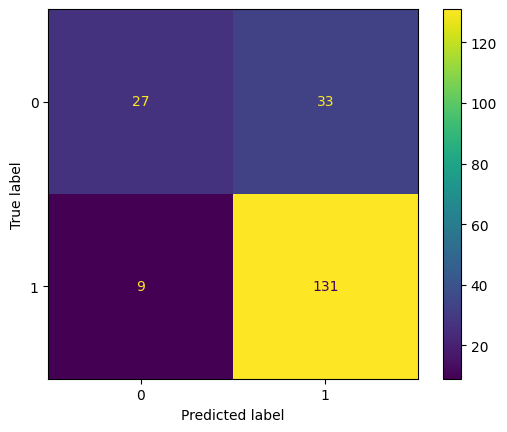

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

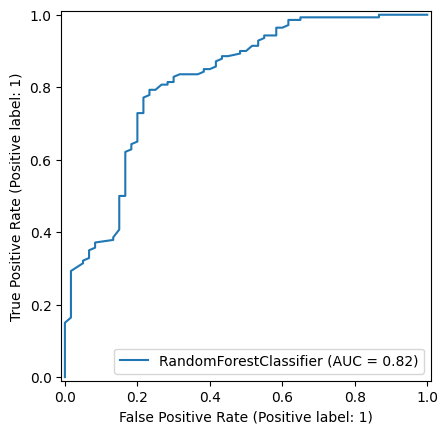

In [84]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)